# Supply Chain Event Streaming - Consumer + Live Dashboard

This notebook combines the consumer and live dashboard into a single pipeline. It reads shipment events from Confluent Cloud Kafka, writes them into Neo4j and refreshes the dashboard on every cycle so you can watch the supply chain graph update in real-time as events arrive.

## Architecture

```
+---------------------------------------------------------+
|                    Confluent Cloud                      |
|                                                         |
|  +------------------+          +---------------------+  |
|  |  Producer        |--------->|    Kafka Topic      |  |
|  |  (other notebook)|          |  shipment-events    |  |
|  +------------------+          +----------+----------+  |
|                                           |             |
+-------------------------------------------+-------------+
                                            |
                               +------------v------------+
                               |  Consumer + Dashboard   |
                               |  (this notebook)        |
                               +------------+------------+
                                            |
                                            v
                               +------------+------------+
                               |     Neo4j AuraDB        |
                               +-------------------------+
```

## Before Running This Notebook

Export these environment variables in your shell before starting Jupyter:

```bash
export CONFLUENT_BOOTSTRAP_SERVERS=your_cluster.confluent.cloud:9092
export CONFLUENT_API_KEY=your_api_key
export CONFLUENT_API_SECRET=your_api_secret
export NEO4J_URI=neo4j+s://xxxx.databases.neo4j.io
export NEO4J_USERNAME=your_username_here
export NEO4J_PASSWORD=your_password_here
export NEO4J_DATABASE=your_database_name_here
```

> **Note:** this notebook uses its own Kafka consumer group ID (`supply-chain-dashboard`). It will catch up on all existing events first, then stay live.

## 1. Install Dependencies

All versions are pinned for reproducibility. Run this cell once.

In [1]:
%pip install "confluent-kafka==2.15.0" \
             "pandas==3.0.5" \
             "plotly==6.9.0" \
             "neo4j==6.2.0" --quiet

print("Install complete.")

Note: you may need to restart the kernel to use updated packages.
Install complete.


## 2. Imports

In [2]:
import json
import os
import pandas as pd
import plotly.graph_objects as go
import time

from collections import defaultdict
from confluent_kafka import Consumer, KafkaError
from IPython.display import clear_output
from neo4j import GraphDatabase
from plotly.subplots import make_subplots

## 3. Configuration

All credentials are read from environment variables. The consumer group ID is set to `supply-chain-dashboard`.

In [3]:
BOOTSTRAP_SERVERS = os.environ["CONFLUENT_BOOTSTRAP_SERVERS"]
API_KEY           = os.environ["CONFLUENT_API_KEY"]
API_SECRET        = os.environ["CONFLUENT_API_SECRET"]
TOPIC             = "shipment-events"
GROUP_ID          = "supply-chain-dashboard"

NEO4J_URI         = os.environ["NEO4J_URI"]
NEO4J_USERNAME    = os.environ["NEO4J_USERNAME"]
NEO4J_PASSWORD    = os.environ["NEO4J_PASSWORD"]
NEO4J_DATABASE    = os.environ["NEO4J_DATABASE"]

POLL_TIMEOUT      = 0.2  # seconds per Kafka poll call
POLL_BATCH        = 20   # max events to consume before refreshing dashboard
REFRESH_INTERVAL  = 5    # seconds between dashboard refreshes

print("Credentials set.")

Credentials set.


## 4. Connect to Neo4j

We connect to Neo4j and verify connectivity before consuming any events.

In [4]:
driver = GraphDatabase.driver(
    NEO4J_URI,
    auth = (NEO4J_USERNAME, NEO4J_PASSWORD),
    notifications_min_severity = "OFF",
)

print(driver.verify_connectivity()) # None is expected
print("Neo4j connection verified.")

None
Neo4j connection verified.


In [5]:
# Create supply chain nodes if they do not already exist.
# This allows the notebook to run standalone.
# MERGE is idempotent - existing nodes are left unchanged.

with driver.session(database = NEO4J_DATABASE) as session:
    for i in range(20):
        session.run("MERGE (:Supplier {id: $id})",            id = f"S{i:03d}")
    for i in range(12):
        session.run("MERGE (:Warehouse {id: $id})",           id = f"W{i:03d}")
    for i in range(10):
        session.run("MERGE (:DistributionCenter {id: $id})",  id = f"DC{i:03d}")
    for i in range(30):
        session.run("MERGE (:Retailer {id: $id})",            id = f"R{i:03d}")
print("Supply chain nodes ready.")

# Clear any Shipment nodes from a previous run so each run starts clean.
with driver.session(database = NEO4J_DATABASE) as session:
    session.run("""
        MATCH (sh:Shipment)
        CALL (sh) { DETACH DELETE sh }
        IN TRANSACTIONS OF 10000 ROWS
    """)
print("Shipment nodes cleared.")

Supply chain nodes ready.
Shipment nodes cleared.


## 5. Simulate a Network Disruption (Optional)

Set `REMOVE_NODE` to any Warehouse or Distribution Center ID to mark it as inactive in Neo4j before the consumer loop starts. The dashboard queries will exclude it and its shipments, so you can watch the impact ripple through the network as new events arrive.

Set `REMOVE_NODE = None` to skip this step and run with the full network.

In [6]:
REMOVE_NODE = None   # e.g. "W003", "DC002", None

if REMOVE_NODE:
    with driver.session(database = NEO4J_DATABASE) as session:
        result = session.run(
            "MATCH (n {id: $id}) SET n.active = false RETURN labels(n)[0] AS label",
            id = REMOVE_NODE
        )
        row = result.single()
        if row:
            print(f"Node {REMOVE_NODE} ({row['label']}) marked as inactive.")
            print("Dashboard will exclude this node and its shipments.")
        else:
            print(f"WARNING: Node {REMOVE_NODE} not found in Neo4j.")
else:
    # Restore all nodes to active in case of a previous run
    with driver.session(database = NEO4J_DATABASE) as session:
        session.run("MATCH (n) WHERE n.active = false REMOVE n.active")
    print("No disruption - full network active.")

No disruption - full network active.


## 6. Create the Kafka Consumer

Setting `auto.offset.reset` to `earliest` ensures this notebook catches up on all events already in the topic before staying live for new ones.

In [7]:
consumer = Consumer({
    "bootstrap.servers": BOOTSTRAP_SERVERS,
    "security.protocol": "SASL_SSL",
    "sasl.mechanisms":   "PLAIN",
    "sasl.username":     API_KEY,
    "sasl.password":     API_SECRET,
    "group.id":          GROUP_ID,
    "auto.offset.reset": "earliest",
    "log_level":         0,
})

consumer.subscribe([TOPIC])
print(f"Consumer subscribed to '{TOPIC}'.")

Consumer subscribed to 'shipment-events'.


## 7. Define the Neo4j Write Logic

Each event enriches the supply chain graph by creating a `Shipment` node and linking it to the existing Supplier, Warehouse, Distribution Center and Retailer nodes. We use `MERGE` on `shipment_id` so re-running this notebook does not create duplicate shipment nodes.

The Cypher query also sets a `last_event_status` property on the warehouse node so we can query which warehouses are currently handling delayed shipments.

In [8]:
WRITE_CYPHER = """
    MERGE (sh:Shipment {shipment_id: $shipment_id})
    SET sh.status        = $status,
        sh.timestamp     = $timestamp,
        sh.delay_minutes = $delay_minutes

    WITH sh
    MATCH (s:Supplier           {id: $supplier_id})
    MATCH (w:Warehouse          {id: $warehouse_id})
    MATCH (dc:DistributionCenter{id: $dist_center_id})
    MATCH (r:Retailer           {id: $retailer_id})

    MERGE (s)-[:HAS_SHIPMENT]->(sh)
    MERGE (sh)-[:VIA_WAREHOUSE]->(w)
    MERGE (sh)-[:VIA_DIST_CENTER]->(dc)
    MERGE (sh)-[:DESTINED_FOR]->(r)

    SET w.last_event_status = $status
"""

def write_event_to_neo4j(session, event):
    """Write a single shipment event into the Neo4j graph."""
    session.run(
        WRITE_CYPHER,
        shipment_id    = event["shipment_id"],
        supplier_id    = event["supplier_id"],
        warehouse_id   = event["warehouse_id"],
        dist_center_id = event["dist_center_id"],
        retailer_id    = event["retailer_id"],
        status         = event["status"],
        timestamp      = event["timestamp"],
        delay_minutes  = event["delay_minutes"],
    )

print("Write logic defined.")

Write logic defined.


## 8. Define the Dashboard Queries

Each query powers one panel of the dashboard. All four run on every refresh cycle so the dashboard always reflects the current state of the graph.

In [9]:
COLOR_MAP = {
    "departed":   "#4C9BE8",
    "in_transit": "#2A9D8F",
    "delayed":    "#E63946",
    "delivered":  "#57CC99",
}

def get_status_summary(session):
    """Shipment counts by status."""
    result = session.run("""
        MATCH (sh:Shipment)
        RETURN sh.status AS status, count(sh) AS count
        ORDER BY count DESC
    """)
    return pd.DataFrame([dict(r) for r in result])

def get_delayed_by_warehouse(session):
    """Delayed shipment count per active warehouse."""
    result = session.run("""
        MATCH (sh:Shipment {status: 'delayed'})-[:VIA_WAREHOUSE]->(w:Warehouse)
        WHERE w.active IS NULL OR w.active <> false
        RETURN w.id AS warehouse, count(sh) AS delayed_shipments
        ORDER BY delayed_shipments DESC
    """)
    return pd.DataFrame([dict(r) for r in result])

def get_delay_by_dist_center(session):
    """Average delay minutes per active distribution center."""
    result = session.run("""
        MATCH (sh:Shipment {status: 'delayed'})-[:VIA_DIST_CENTER]->(dc:DistributionCenter)
        WHERE dc.active IS NULL OR dc.active <> false
        RETURN dc.id AS dist_center,
               round(avg(sh.delay_minutes), 1) AS avg_delay_minutes
        ORDER BY avg_delay_minutes DESC
    """)
    return pd.DataFrame([dict(r) for r in result])

def get_shipment_flow(session):
    """Shipment volume from suppliers to active warehouses (top 15 paths)."""
    result = session.run("""
        MATCH (s:Supplier)-[:HAS_SHIPMENT]->(sh:Shipment)
              -[:VIA_WAREHOUSE]->(w:Warehouse)
        WHERE w.active IS NULL OR w.active <> false
        RETURN s.id AS source, w.id AS target, count(sh) AS volume
        ORDER BY volume DESC
        LIMIT 15
    """)
    return pd.DataFrame([dict(r) for r in result])

def get_retailer_impact(session):
    """Delayed shipment count per retailer."""
    result = session.run("""
        MATCH (sh:Shipment {status: 'delayed'})-[:DESTINED_FOR]->(r:Retailer)
        RETURN r.id AS retailer, count(sh) AS delayed_shipments
        ORDER BY delayed_shipments DESC
        LIMIT 15
    """)
    return pd.DataFrame([dict(r) for r in result])

def get_warehouse_health(session):
    """Route health score per warehouse: 1 - (delayed / total)."""
    result = session.run("""
        MATCH (sh:Shipment)-[:VIA_WAREHOUSE]->(w:Warehouse)
        WHERE w.active IS NULL OR w.active <> false
        WITH w.id AS warehouse,
             count(sh) AS total,
             count(CASE WHEN sh.status = 'delayed' THEN 1 END) AS delayed
        RETURN warehouse,
               total,
               delayed,
               round(1.0 - toFloat(delayed) / total, 3) AS health_score
        ORDER BY warehouse
    """)
    return pd.DataFrame([dict(r) for r in result])

def get_supplier_performance(session):
    """Delayed shipment count per supplier."""
    result = session.run("""
        MATCH (s:Supplier)-[:HAS_SHIPMENT]->(sh:Shipment {status: 'delayed'})
        RETURN s.id AS supplier, count(sh) AS delayed_shipments
        ORDER BY delayed_shipments DESC
        LIMIT 15
    """)
    return pd.DataFrame([dict(r) for r in result])

def get_network_status(session):
    """High-level network health summary."""
    result = session.run("""
        MATCH (sh:Shipment)
        WITH count(sh) AS total,
             count(CASE WHEN sh.status = 'delayed' THEN 1 END) AS delayed
        OPTIONAL MATCH (n) WHERE n.active = false
        RETURN total,
               delayed,
               CASE WHEN total > 0
                    THEN round(100.0 * delayed / total, 1)
                    ELSE 0.0 END AS delay_rate_pct,
               collect(n.id) AS disabled_nodes
    """)
    row = result.single()
    return dict(row) if row else {}

print("Dashboard queries defined.")

Dashboard queries defined.


## 9. Define the Dashboard Layout

We build all panels as a single Plotly figure on each refresh. Using `make_subplots` with a grid keeps all charts visible at once.

In [10]:
def build_dashboard(df_status, df_delayed, df_dc, df_flow,
                    df_retailer, df_health, df_supplier,
                    network_status, events_consumed, refresh_count):
    """Build the 4x2 dashboard figure from the latest Neo4j data."""
    total        = network_status.get("total", 0) or 0
    delayed      = network_status.get("delayed", 0) or 0
    delay_rate   = network_status.get("delay_rate_pct", 0.0) or 0.0
    disabled     = network_status.get("disabled_nodes", []) or []
    disabled_str = ", ".join(disabled) if disabled else "None"

    fig = make_subplots(
        rows = 4, cols = 2,
        subplot_titles = (
            "Network Status",                            "Shipment Status Distribution",
            "Delayed Shipments by Warehouse",            "Warehouse Health Score",
            "Supplier Performance - Delayed Shipments",  "Retailer Impact - Delayed Shipments",
            "Avg Delay by Distribution Center (min)",    "Shipment Flow - Suppliers to Warehouses",
        ),
        specs = [
            [{"type": "table"}, {"type": "pie"}],
            [{"type": "bar"},   {"type": "heatmap"}],
            [{"type": "bar"},   {"type": "bar"}],
            [{"type": "bar"},   {"type": "sankey"}],
        ],
        vertical_spacing = 0.07,
    )

    # Panel 1 - network status table
    fig.add_trace(go.Table(
        header = dict(
            values     = ["Metric", "Value"],
            fill_color = "#2A9D8F",
            font       = dict(color = "white", size = 12),
            align      = "left",
        ),
        cells = dict(
            values = [
                ["Total Shipments", "Delayed", "Delay Rate",
                 "Kafka Consumed", "Refreshes", "Disabled Nodes"],
                [total, delayed, f"{delay_rate}%",
                 events_consumed, refresh_count, disabled_str],
            ],
            fill_color = [["#f9f9f9", "white"] * 3],
            align      = "left",
            font       = dict(size = 11),
        ),
    ), row = 1, col = 1)

    # Panel 2 - status donut
    if not df_status.empty:
        fig.add_trace(go.Pie(
            labels        = df_status["status"].tolist(),
            values        = df_status["count"].tolist(),
            marker_colors = [COLOR_MAP.get(s, "#999") for s in df_status["status"]],
            hole          = 0.4,
            textinfo      = "label+percent+value",
            showlegend    = False,
        ), row = 1, col = 2)

    # Panel 3 - delayed by warehouse
    if not df_delayed.empty:
        fig.add_trace(go.Bar(
            x            = df_delayed["warehouse"].tolist(),
            y            = df_delayed["delayed_shipments"].tolist(),
            marker_color = "#E63946",
            text         = df_delayed["delayed_shipments"].tolist(),
            textposition = "outside",
            showlegend   = False,
        ), row = 2, col = 1)

    # Panel 4 - warehouse health heatmap
    if not df_health.empty:
        fig.add_trace(go.Heatmap(
            z            = [df_health["health_score"].tolist()],
            x            = df_health["warehouse"].tolist(),
            y            = ["Health"],
            colorscale   = [[0.0, "#E63946"], [0.5, "#F4A261"], [1.0, "#57CC99"]],
            zmin         = 0,
            zmax         = 1,
            text         = [[f"{v:.2f}" for v in df_health["health_score"].tolist()]],
            texttemplate = "%{text}",
            showscale    = False,
        ), row = 2, col = 2)

    # Panel 5 - supplier performance
    if not df_supplier.empty:
        fig.add_trace(go.Bar(
            x            = df_supplier["supplier"].tolist(),
            y            = df_supplier["delayed_shipments"].tolist(),
            marker_color = "#E9C46A",
            text         = df_supplier["delayed_shipments"].tolist(),
            textposition = "outside",
            showlegend   = False,
        ), row = 3, col = 1)

    # Panel 6 - retailer impact
    if not df_retailer.empty:
        fig.add_trace(go.Bar(
            x            = df_retailer["retailer"].tolist(),
            y            = df_retailer["delayed_shipments"].tolist(),
            marker_color = "#7B68EE",
            text         = df_retailer["delayed_shipments"].tolist(),
            textposition = "outside",
            showlegend   = False,
        ), row = 3, col = 2)

    # Panel 7 - avg delay by DC
    if not df_dc.empty:
        fig.add_trace(go.Bar(
            x            = df_dc["dist_center"].tolist(),
            y            = df_dc["avg_delay_minutes"].tolist(),
            marker_color = "#F4A261",
            text         = df_dc["avg_delay_minutes"].tolist(),
            textposition = "outside",
            showlegend   = False,
        ), row = 4, col = 1)

    # Panel 8 - Sankey flow
    if not df_flow.empty:
        all_nodes = list(set(df_flow["source"].tolist() + df_flow["target"].tolist()))
        node_idx  = {n: i for i, n in enumerate(all_nodes)}
        fig.add_trace(go.Sankey(
            node = dict(
                label = all_nodes,
                color = ["#4C9BE8" if n.startswith("S") else "#F4A261"
                         for n in all_nodes],
            ),
            link = dict(
                source = [node_idx[r["source"]] for _, r in df_flow.iterrows()],
                target = [node_idx[r["target"]] for _, r in df_flow.iterrows()],
                value  = [1] * len(df_flow),
            ),
        ), row = 4, col = 2)

    fig.update_layout(
        height        = 1600,
        plot_bgcolor  = "white",
        paper_bgcolor = "white",
        margin        = dict(l = 40, r = 40, t = 40, b = 40),
    )
    return fig

print("Dashboard layout defined.")

Dashboard layout defined.


## 10. Consume Events and Refresh the Dashboard

This cell is the main loop. On each cycle it:

1. Polls Kafka for up to `POLL_BATCH` new events and writes them to Neo4j
2. Queries Neo4j for the current graph state
3. Rebuilds and redraws the dashboard
4. Sleeps for `REFRESH_INTERVAL` seconds before repeating

The loop catches up on all existing Kafka events first, then stays live for new ones. Interrupt the kernel to stop.

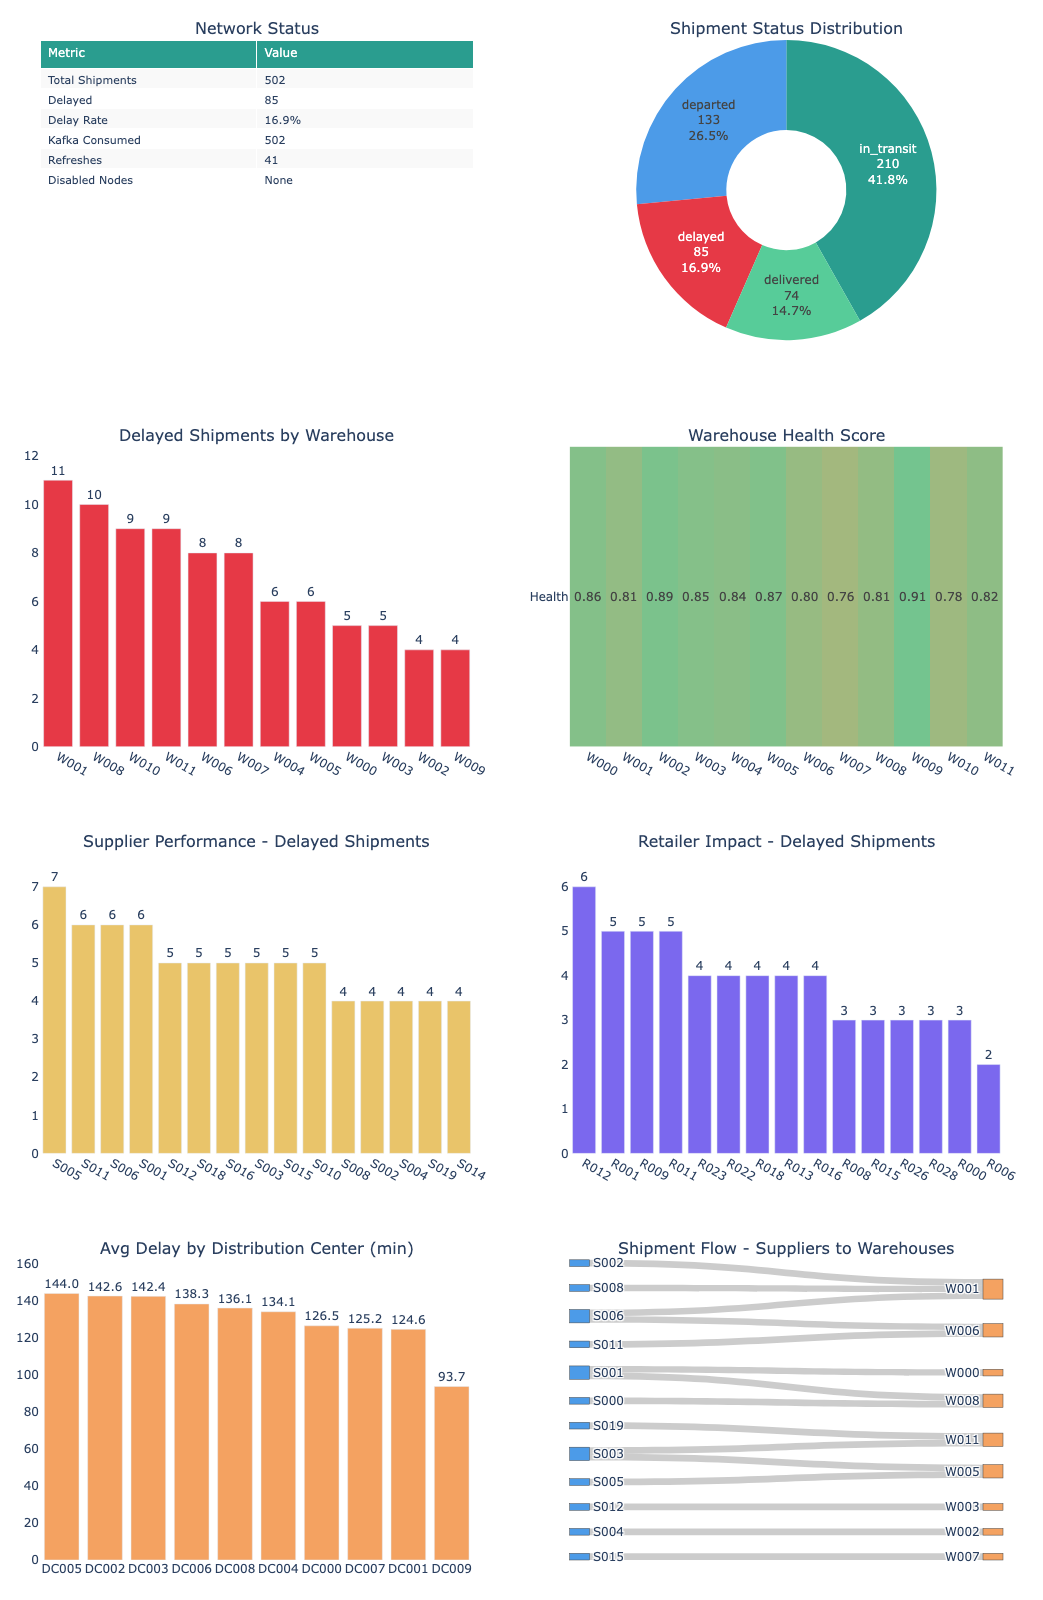


Stopped after 41 refreshes, 502 events consumed.

Final status breakdown:
  delayed      : 85
  delivered    : 74
  departed     : 133
  in_transit   : 210


In [11]:
events_consumed = 0
refresh_count   = 0
status_counts   = defaultdict(int)

print(f"Starting consumer + dashboard loop...")
print(f"Polling up to {POLL_BATCH} events per cycle, refreshing every {REFRESH_INTERVAL}s.")
print("Interrupt kernel to stop.\n")

try:
    while True:
        # Step 1 - consume a batch of events from Kafka and write to Neo4j
        with driver.session(database = NEO4J_DATABASE) as session:
            for _ in range(POLL_BATCH):
                msg = consumer.poll(timeout = POLL_TIMEOUT)

                if msg is None:
                    break

                if msg.error():
                    if msg.error().code() == KafkaError._PARTITION_EOF:
                        break
                    print(f"Consumer error: {msg.error()}")
                    break

                event = json.loads(msg.value().decode("utf-8"))
                write_event_to_neo4j(session, event)
                status_counts[event["status"]] += 1
                events_consumed += 1

        # Step 2 - query Neo4j for current state
        with driver.session(database = NEO4J_DATABASE) as session:
            df_status      = get_status_summary(session)
            df_delayed     = get_delayed_by_warehouse(session)
            df_dc          = get_delay_by_dist_center(session)
            df_flow        = get_shipment_flow(session)
            df_retailer    = get_retailer_impact(session)
            df_health      = get_warehouse_health(session)
            df_supplier    = get_supplier_performance(session)
            network_status = get_network_status(session)

        # Step 3 - rebuild and redraw the dashboard
        refresh_count += 1
        fig = build_dashboard(
            df_status, df_delayed, df_dc, df_flow,
            df_retailer, df_health, df_supplier,
            network_status, events_consumed, refresh_count
        )
        clear_output(wait = True)
        fig.show()

        # Step 4 - sleep before next cycle
        time.sleep(REFRESH_INTERVAL)

except KeyboardInterrupt:
    print(f"\nStopped after {refresh_count} refreshes, {events_consumed} events consumed.")
    print("\nFinal status breakdown:")
    for status, count in sorted(status_counts.items()):
        print(f"  {status:<12} : {count}")

### Live Disruption - No Restart Needed

While the dashboard is running you can disable or re-enable any node at any time using the Neo4j Browser or AuraDB Query tab. The dashboard will reflect the change on the next refresh cycle (within `REFRESH_INTERVAL` seconds).

#### Disable a node:

```cypher
MATCH (n {id: "W003"})
SET n.active = false
RETURN n.id, labels(n)[0] AS label, n.active
```

#### Re-enable a node:

```cypher
MATCH (n {id: "W003"})
REMOVE n.active
RETURN n.id, labels(n)[0] AS label
```

#### Check which nodes are currently disabled:

```cypher
MATCH (n)
WHERE n.active = false
RETURN labels(n)[0] AS label, n.id AS id
```

## 11. Teardown

Close all connections.

In [12]:
consumer.close()
driver.close()
print("Consumer and Neo4j connections closed.")

Consumer and Neo4j connections closed.
